In [1]:
import pandas as pd

# Load the 311 food poisoning complaints dataset
food_poisoning_df = pd.read_csv("food_poisoning.csv")

# Load the restaurant inspection results dataset
restaurant_inspection_df = pd.read_csv("restaurant_inspection.csv")

# Rename columns to ensure consistency
# For 311 food poisoning dataset
food_poisoning_df.rename(columns={
    "Incident Zip": "ZIPCODE",  # Ensuring the ZIP code column has the same name
    "Borough": "Borough",  # Standardizing the name of the borough column
    "Latitude": "Latitude",  # Ensure geospatial columns are named the same
    "Longitude": "Longitude",
}, inplace=True)

# For restaurant inspection dataset
restaurant_inspection_df.rename(columns={
    "BORO": "Borough",  # Standardizing the borough column name
    "ZIPCODE": "ZIPCODE",  # Standardizing ZIP code column name
    "Latitude": "Latitude",  # Geospatial columns
    "Longitude": "Longitude",
}, inplace=True)

# Check the first few rows of both datasets to verify
print(food_poisoning_df.head())
print(restaurant_inspection_df.head())


   Unique Key            Created Date Closed Date Agency  \
0    64782037  04/29/2025 01:31:54 AM         NaN  DOHMH   
1    64786033  04/29/2025 12:26:00 AM         NaN  DOHMH   
2    64782005  04/28/2025 06:44:32 PM         NaN  DOHMH   
3    64788814  04/28/2025 03:51:57 PM         NaN  DOHMH   
4    64784982  04/28/2025 11:52:35 AM         NaN  DOHMH   

                               Agency Name  Complaint Type Descriptor  \
0  Department of Health and Mental Hygiene  Food Poisoning     1 or 2   
1  Department of Health and Mental Hygiene  Food Poisoning     1 or 2   
2  Department of Health and Mental Hygiene  Food Poisoning  3 or More   
3  Department of Health and Mental Hygiene  Food Poisoning     1 or 2   
4  Department of Health and Mental Hygiene  Food Poisoning     1 or 2   

                Location Type  ZIPCODE         Incident Address  ...  \
0  Restaurant/Bar/Deli/Bakery  10024.0     509 AMSTERDAM AVENUE  ...   
1  Restaurant/Bar/Deli/Bakery  10012.0           55 BOND

In [2]:
# For the food poisoning complaints dataset, keep only the relevant columns
food_poisoning_df = food_poisoning_df[["ZIPCODE", "Longitude", "Latitude", "Borough"]]

# For the restaurant inspection dataset, keep only the relevant columns
restaurant_inspection_df = restaurant_inspection_df[["DBA", "ZIPCODE", "Longitude", "Latitude", "VIOLATION CODE", "Borough"]]

# Check the cleaned datasets
print(food_poisoning_df.head())
print(restaurant_inspection_df.head())


   ZIPCODE  Longitude   Latitude    Borough
0  10024.0 -73.975751  40.786657  MANHATTAN
1  10012.0 -73.992629  40.725907  MANHATTAN
2  11205.0 -73.975336  40.699033   BROOKLYN
3  11412.0 -73.755777  40.693460     QUEENS
4  10012.0 -73.995624  40.721189  MANHATTAN
                   DBA  ZIPCODE  Longitude   Latitude VIOLATION CODE  \
0        PAO DE QUEIJO  11106.0 -73.926059  40.762516            NaN   
1  JOHN'S PANINI GRILL  11101.0 -73.944407  40.759071            NaN   
2  TRIPLE BROTHER INC.  11354.0 -73.829235  40.759778            NaN   
3       ANGRY ARCHIE'S  10001.0 -73.987541  40.750542            NaN   
4         UPSIDE PIZZA  10025.0 -73.965821  40.805347            NaN   

     Borough  
0     Queens  
1     Queens  
2     Queens  
3  Manhattan  
4  Manhattan  


In [3]:
# Drop rows with missing geographic data
food_poisoning_df = food_poisoning_df.dropna(subset=["ZIPCODE", "Longitude", "Latitude", "Borough"])
restaurant_inspection_df = restaurant_inspection_df.dropna(subset=["ZIPCODE", "Longitude", "Latitude", "Borough"])

# Check again for any remaining missing values
print(food_poisoning_df.isnull().sum())
print(restaurant_inspection_df.isnull().sum())


ZIPCODE      0
Longitude    0
Latitude     0
Borough      0
dtype: int64
DBA                  2
ZIPCODE              0
Longitude            0
Latitude             0
VIOLATION CODE    4562
Borough              0
dtype: int64


In [4]:
# Merge the datasets on ZIP and Borough
merged_data = pd.merge(restaurant_inspection_df, food_poisoning_df, on=["ZIPCODE", "Borough"], how="inner")

# Check the merged dataset
print(merged_data.head())


Empty DataFrame
Columns: [DBA, ZIPCODE, Longitude_x, Latitude_x, VIOLATION CODE, Borough, Longitude_y, Latitude_y]
Index: []


In [5]:
# Check for duplicates in the merged dataset
merged_data = merged_data.drop_duplicates()

# Check if any missing values are left
print(merged_data.isnull().sum())

# Final check of the merged dataset
print(merged_data.head())


DBA               0
ZIPCODE           0
Longitude_x       0
Latitude_x        0
VIOLATION CODE    0
Borough           0
Longitude_y       0
Latitude_y        0
dtype: int64
Empty DataFrame
Columns: [DBA, ZIPCODE, Longitude_x, Latitude_x, VIOLATION CODE, Borough, Longitude_y, Latitude_y]
Index: []


In [6]:
# Check unique values in the ZIP and Borough columns of both datasets
print("Food Poisoning Dataset - ZIP codes:", food_poisoning_df["ZIPCODE"].unique())
print("Food Poisoning Dataset - Boroughs:", food_poisoning_df["Borough"].unique())

print("Restaurant Inspection Dataset - ZIP codes:", restaurant_inspection_df["ZIPCODE"].unique())
print("Restaurant Inspection Dataset - Boroughs:", restaurant_inspection_df["Borough"].unique())


Food Poisoning Dataset - ZIP codes: [10024. 10012. 11205. 11412. 11417. 11218. 10033. 10036. 11385. 10309.
 11237. 10009. 10028. 10018. 11365. 10029. 11428. 11372. 11208. 11433.
 10011. 11109. 11361. 10001. 10022. 11216. 11231. 10458. 10475. 10462.
 10465. 10025. 11366. 10017. 11419. 11217. 10467. 11413. 10128. 11435.
 10453. 10027. 11201. 11220. 11215. 11106. 10016. 11354. 11101. 11223.
 10310. 11235. 11206. 10019. 10003. 11232. 11211. 10039. 10030. 10010.
 11222. 10004. 11434. 11355. 10013. 11379. 11230. 11368. 10282. 10306.
 10456. 11239. 10026. 10463. 11415. 11238. 11105. 11693. 10007. 11692.
 10038. 11207. 10075. 10314. 11375. 10034. 10452. 10032. 10451. 10281.
 11373. 10002. 11209. 10472. 10460. 10021. 11228. 10119. 11249. 10459.
 10065. 11219. 11004. 10470. 10014. 11427. 11212. 11374. 11423. 10312.
 11104. 10023. 11224. 11416. 11221. 11430. 10468. 10457. 10280. 11364.
 11229. 10037. 11367. 11370. 11210. 10461. 11225. 11103. 11418. 10040.
 10301. 11226. 10469. 11204. 11420. 11432

In [7]:
# Standardize ZIP codes and Boroughs in both datasets
food_poisoning_df["ZIPCODE"] = food_poisoning_df["ZIPCODE"].astype(str).str.strip().str.zfill(5)  # Ensure 5-digit ZIP codes
food_poisoning_df["Borough"] = food_poisoning_df["Borough"].str.strip().str.upper()  # Uppercase Borough names

restaurant_inspection_df["ZIPCODE"] = restaurant_inspection_df["ZIPCODE"].astype(str).str.strip().str.zfill(5)
restaurant_inspection_df["Borough"] = restaurant_inspection_df["Borough"].str.strip().str.upper()

# Handle specific cases for "Unspecified" boroughs or any anomalies if needed
food_poisoning_df["Borough"] = food_poisoning_df["Borough"].replace({"UNSPECIFIED": "UNKNOWN"})
restaurant_inspection_df["Borough"] = restaurant_inspection_df["Borough"].replace({"UNSPECIFIED": "UNKNOWN"})

# Check the cleaned columns
print(food_poisoning_df[["ZIPCODE", "Borough"]].head())
print(restaurant_inspection_df[["ZIPCODE", "Borough"]].head())


   ZIPCODE    Borough
0  10024.0  MANHATTAN
1  10012.0  MANHATTAN
2  11205.0   BROOKLYN
3  11412.0     QUEENS
4  10012.0  MANHATTAN
   ZIPCODE    Borough
0  11106.0     QUEENS
1  11101.0     QUEENS
2  11354.0     QUEENS
3  10001.0  MANHATTAN
4  10025.0  MANHATTAN


In [8]:
# Merge the datasets on ZIP and Borough
merged_data = pd.merge(restaurant_inspection_df, food_poisoning_df, on=["ZIPCODE", "Borough"], how="inner")

# Check the merged data
print(merged_data.head())


             DBA  ZIPCODE  Longitude_x  Latitude_x VIOLATION CODE Borough  \
0  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS   
1  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS   
2  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS   
3  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS   
4  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS   

   Longitude_y  Latitude_y  
0   -73.921655   40.763459  
1   -73.920944   40.763126  
2   -73.936581   40.759776  
3   -73.925169   40.761861  
4   -73.930723   40.766275  


In [9]:
# Drop one set of longitude and latitude columns (either _x or _y)
merged_data.drop(columns=["Longitude_y", "Latitude_y"], inplace=True)  # or vice versa, depending on your preference

# Check the cleaned merged dataset
print(merged_data.head())


             DBA  ZIPCODE  Longitude_x  Latitude_x VIOLATION CODE Borough
0  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS
1  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS
2  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS
3  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS
4  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS


In [10]:
# Create a copy of the merged_data DataFrame
merged_data_copy = merged_data.copy()

# Check the first few rows of the copied data
print(merged_data_copy.head())


             DBA  ZIPCODE  Longitude_x  Latitude_x VIOLATION CODE Borough
0  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS
1  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS
2  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS
3  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS
4  PAO DE QUEIJO  11106.0   -73.926059   40.762516            NaN  QUEENS


In [11]:
# Convert the columns to strings (handling NaN values by converting them to 'Missing')
merged_data_copy['VIOLATION CODE'] = merged_data_copy['VIOLATION CODE'].fillna('Missing').astype(str)


# Group by restaurant (DBA) and aggregate the violation information into one row
aggregated_data = merged_data_copy.groupby('DBA').agg({
    'ZIPCODE': 'first',  # Take the first ZIP code (it should be the same for each restaurant)
    'Longitude_x': 'first',  # Keep the first Longitude value
    'Latitude_x': 'first',  # Keep the first Latitude value
    'VIOLATION CODE': lambda x: ', '.join(x.unique()),  # Concatenate all violation codes into a single string
    'Borough': 'first',  # Take the first Borough (same for each restaurant)
}).reset_index()

# Check the aggregated data
print(aggregated_data.head())


                            DBA  ZIPCODE  Longitude_x  Latitude_x  \
0     "U" LIKE CHINESE TAKE OUT  10034.0   -73.921726   40.867494   
1                      "W" CAFE  10018.0   -73.984080   40.749800   
2  #1 GARDEN CHINESE RESTAURANT  11215.0   -73.980555   40.660156   
3    #1 SABOR LATINO RESTAURANT  10466.0   -73.858591   40.891176   
4                      $1 PIZZA  10001.0   -73.990158   40.746510   

                                      VIOLATION CODE    Borough  
0        06C, 04M, 06F, 08A, 02G, 04N, 02B, 06A, 04H  MANHATTAN  
1                     04N, 02G, 20-06, 10G, 04M, 08A  MANHATTAN  
2  02B, 08A, 10F, 04N, 04L, 09B, 06F, 09C, 06B, 0...   BROOKLYN  
3  04L, 02B, 06F, 02H, 10F, 08A, 10B, 06D, 02G, 0...      BRONX  
4  02B, 04N, 10B, 20-06, 04M, Missing, 02G, 02H, ...  MANHATTAN  


In [12]:
# Save the cleaned aggregated data to a CSV file
aggregated_data.to_csv('aggregated_violations_data.csv', index=False)

# Check the saved file
print(aggregated_data.head())


                            DBA  ZIPCODE  Longitude_x  Latitude_x  \
0     "U" LIKE CHINESE TAKE OUT  10034.0   -73.921726   40.867494   
1                      "W" CAFE  10018.0   -73.984080   40.749800   
2  #1 GARDEN CHINESE RESTAURANT  11215.0   -73.980555   40.660156   
3    #1 SABOR LATINO RESTAURANT  10466.0   -73.858591   40.891176   
4                      $1 PIZZA  10001.0   -73.990158   40.746510   

                                      VIOLATION CODE    Borough  
0        06C, 04M, 06F, 08A, 02G, 04N, 02B, 06A, 04H  MANHATTAN  
1                     04N, 02G, 20-06, 10G, 04M, 08A  MANHATTAN  
2  02B, 08A, 10F, 04N, 04L, 09B, 06F, 09C, 06B, 0...   BROOKLYN  
3  04L, 02B, 06F, 02H, 10F, 08A, 10B, 06D, 02G, 0...      BRONX  
4  02B, 04N, 10B, 20-06, 04M, Missing, 02G, 02H, ...  MANHATTAN  


In [31]:
import pandas as pd
import folium

# Assuming 'aggregated_data' is your cleaned dataset with latitude, longitude, Violation Severity, and DBA (restaurant name)
# Ensure your DataFrame includes the columns: 'Latitude', 'Longitude', 'Violation Severity', 'DBA'

# Map severity to colors
severity_colors = {
    'Critical': 'red',
    'Public Health Hazard': 'orange',
    'General': 'green'
}

# Create a map centered around NYC
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=12)

# Iterate through the rows in the dataset and plot each violation on the map
for idx, row in aggregated_data.iterrows():
    # Get severity color based on the violation severity
    color = severity_colors.get(row['Violation Severity'], 'gray')  # Default to gray if not found

    # Create popup content with restaurant name (DBA), violation code, and severity
    popup_content = f"Restaurant: {row['DBA']}<br>Violation Code: {row['VIOLATION CODE']}<br>Severity: {row['Violation Severity']}"

    folium.CircleMarker(
        location=[row['Latitude_x'], row['Longitude_x']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=popup_content
    ).add_to(nyc_map)

# Save map to an HTML file
nyc_map.save('restaurant_violations_map_with_dba_names.html')


In [29]:
import pandas as pd
import folium

# Assuming 'aggregated_data' is your cleaned dataset with latitude, longitude, and Violation Severity
# Make sure your DataFrame includes the columns: 'Latitude', 'Longitude', and 'Violation Severity'

# Map severity to colors
severity_colors = {
    'Critical': 'red',
    'Public Health Hazard': 'orange',
    'General': 'green'
}

# Create a map centered around NYC
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=12)

# Iterate through the rows in the dataset and plot each violation on the map
for idx, row in aggregated_data.iterrows():
    # Get severity color based on the violation severity
    color = severity_colors.get(row['Violation Severity'], 'gray')  # Default to gray if not found

    folium.CircleMarker(
        location=[row['Latitude_x'], row['Longitude_x']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=f"Violation Code: {row['VIOLATION CODE']}, Severity: {row['Violation Severity']}"
    ).add_to(nyc_map)

# Save map to an HTML file
nyc_map.save('restaurant_violations_map.html')


In [13]:
# Define a dictionary mapping violation codes to severity levels
violation_mapping = {
    '02A': 'Public Health Hazard',  # Poultry not heated to the required temperature
    '02B': 'Public Health Hazard',  # Hot food not held at required temperature
    '02C': 'Critical',  # Reheated food not to the proper temperature
    '02D': 'Critical',  # Commercially processed food not heated properly
    '02E': 'Critical',  # Frozen poultry improperly cooked
    '02F': 'Critical',  # Raw or undercooked meat, fish, shellfish
    '02G': 'Public Health Hazard',  # Cold food not held at proper temperature
    '03A': 'Public Health Hazard',  # Food from an unapproved source
    '03B': 'Public Health Hazard',  # Improperly tagged or labeled shellfish
    '04A': 'Critical',  # Food protection certificate not held by supervisor
    '04B': 'Public Health Hazard',  # Ill food worker preparing food
    '04C': 'Public Health Hazard',  # Bare hand contact with ready-to-eat foods
    '04D': 'Public Health Hazard',  # Worker failed to wash hands after contamination
    '04E': 'Public Health Hazard',  # Improper pesticide use
    '04F': 'Public Health Hazard',  # Sewage disposal issues
    '04G': 'Public Health Hazard',  # Unprotected hazardous food re-served
    '04H': 'Public Health Hazard',  # Cross-contamination of food
    '04I': 'Critical',  # Food served in unsealed packages
    '05A': 'Public Health Hazard',  # Improper sewage disposal
    '05B': 'Public Health Hazard',  # Harmful gas/vapor detected
    '05C': 'Critical',  # Improper food contact surface
    '06A': 'Critical',  # Food worker not maintaining cleanliness
    '06B': 'Critical',  # Smoking or eating in food prep areas
    '06C': 'Critical',  # Improper food protection during storage
    '08A': 'Critical',  # Pest conditions observed
    '08B': 'General',  # Improper garbage removal
    '08C': 'General',  # Improper pesticide storage or use
    '09A': 'General',  # Improperly dented food cans
    '09B': 'General',  # Improper thawing procedures
    '10A': 'General',  # Toilet facility issues
    '10B': 'General',  # Sewage issues
    '10C': 'General',  # Lighting and ventilation issues
    '10D': 'General',  # Improper ware washing procedures
    # Additional codes can be mapped as per the same pattern
}

# Function to apply the severity level to each violation code
def assign_severity(violation_code):
    return violation_mapping.get(violation_code, 'General')  # Default to 'General' if not found

# Apply the function to the 'Violation Code' column
aggregated_data['Violation Severity'] = aggregated_data['VIOLATION CODE'].apply(assign_severity)

# Check the result
print(aggregated_data[['DBA', 'VIOLATION CODE', 'Violation Severity']].head())


                            DBA  \
0     "U" LIKE CHINESE TAKE OUT   
1                      "W" CAFE   
2  #1 GARDEN CHINESE RESTAURANT   
3    #1 SABOR LATINO RESTAURANT   
4                      $1 PIZZA   

                                      VIOLATION CODE Violation Severity  
0        06C, 04M, 06F, 08A, 02G, 04N, 02B, 06A, 04H            General  
1                     04N, 02G, 20-06, 10G, 04M, 08A            General  
2  02B, 08A, 10F, 04N, 04L, 09B, 06F, 09C, 06B, 0...            General  
3  04L, 02B, 06F, 02H, 10F, 08A, 10B, 06D, 02G, 0...            General  
4  02B, 04N, 10B, 20-06, 04M, Missing, 02G, 02H, ...            General  


In [14]:
# Check the column names in the merged_data DataFrame
print(aggregated_data.columns)


Index(['DBA', 'ZIPCODE', 'Longitude_x', 'Latitude_x', 'VIOLATION CODE',
       'Borough', 'Violation Severity'],
      dtype='object')


In [21]:
# Define the severity levels in priority order
severity_order = ['Critical', 'Public Health Hazard', 'General']

# Function to assign priority severity based on violation codes
def get_priority_severity(violaion_codes):
    # Initialize the priority severity as 'General'
    priority_severity = 'General'
    
    # Check for Critical violations first
    if 'Critical' in VIOLATION CODE:
        priority_severity = 'Critical'
    # Check for Public Health Hazard violations if no Critical
    elif 'Public Health Hazard' in VIOLATION CODE:
        priority_severity = 'Public Health Hazard'
    
    return priority_severity

# Apply the function to assign priority severity for each restaurant (DBA)
aggregated_data['Priority Severity'] = aggregated_data['Violation Severity'].apply(get_priority_severity)

# Check the final dataset
print(aggregated_data[['DBA', 'VIOLATION CODE', 'Priority Severity']].head())


SyntaxError: invalid syntax (4142741610.py, line 10)

In [22]:
# Define the severity levels in priority order
severity_order = ['Critical', 'Public Health Hazard', 'General']

# Function to assign priority severity based on violation codes
def get_priority_severity(violation_codes):
    # Initialize the priority severity as 'General'
    priority_severity = 'General'
    
    # Check for Critical violations first
    if 'Critical' in violation_codes:
        priority_severity = 'Critical'
    # Check for Public Health Hazard violations if no Critical
    elif 'Public Health Hazard' in violation_codes:
        priority_severity = 'Public Health Hazard'
    
    return priority_severity

# Apply the function to assign priority severity for each restaurant (DBA)
aggregated_data['Priority Severity'] = aggregated_data['Violation Severity'].apply(get_priority_severity)

# Check the final dataset
print(aggregated_data[['DBA', 'VIOLATION CODE', 'Priority Severity']].head())


                            DBA  \
0     "U" LIKE CHINESE TAKE OUT   
1                      "W" CAFE   
2  #1 GARDEN CHINESE RESTAURANT   
3    #1 SABOR LATINO RESTAURANT   
4                      $1 PIZZA   

                                                                                   VIOLATION CODE  \
0                                                     06C, 04M, 06F, 08A, 02G, 04N, 02B, 06A, 04H   
1                                                                  04N, 02G, 20-06, 10G, 04M, 08A   
2                          02B, 08A, 10F, 04N, 04L, 09B, 06F, 09C, 06B, 04M, 06A, 28-06, 02G, 09A   
3                                           04L, 02B, 06F, 02H, 10F, 08A, 10B, 06D, 02G, 04H, 04M   
4  02B, 04N, 10B, 20-06, 04M, Missing, 02G, 02H, 06B, 04L, 06C, 10D, 06F, 04H, 10F, 08A, 04A, 05D   

  Priority Severity  
0           General  
1           General  
2           General  
3           General  
4           General  


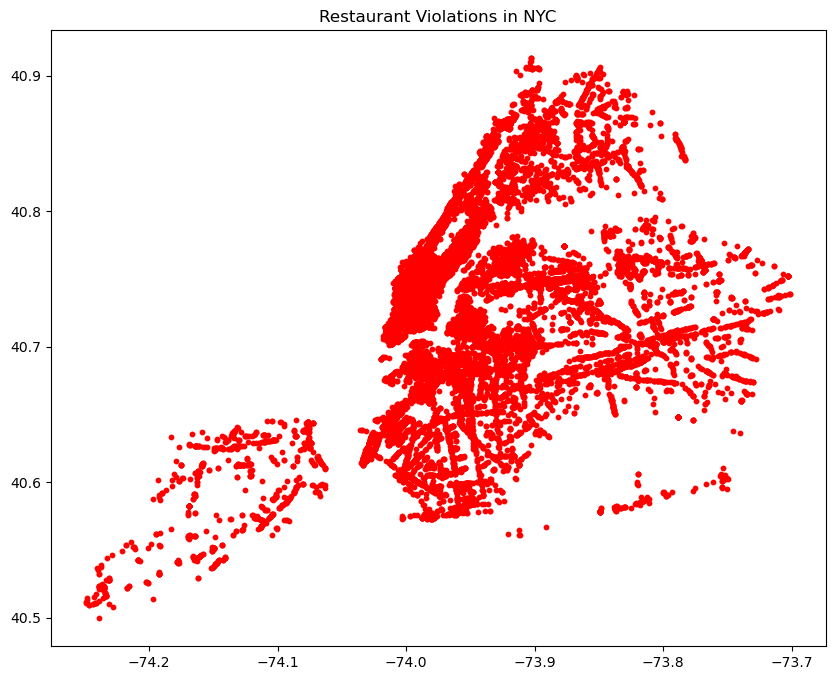

In [18]:
import matplotlib.pyplot as plt

# Create a smaller figure size for the plot (e.g., 10 x 8 inches)
plt.figure(figsize=(10, 8))  # Adjust this size as needed

# Your plotting code here (e.g., scatter plot, heatmap, etc.)
# Example plot:
plt.scatter(aggregated_data['Longitude_x'], aggregated_data['Latitude_x'], c='red', s=10)
plt.title("Restaurant Violations in NYC")

# Save the plot with a smaller size
plt.savefig('smaller_map.png', dpi=300)

# Show the plot
plt.show()
